Assignment 2: ML Model Training & Evaluation

#Data Ingestion
Reused from assignment 1.

In [ ]:
#Download "yellow_tripdata_2024-01.parquet" and "taxi_zone_lookup.csv" files to "data/raw/" directory:
import os
import urllib.request

os.makedirs("data/raw/", exist_ok=True)

urllib.request.urlretrieve(
    "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet",
    "data/raw/yellow_tripdata_2024-01.parquet"
)

urllib.request.urlretrieve(
    "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv",
    "data/raw/taxi_zone_lookup.csv"
)

print("Files downloaded successfully.")

Files downloaded successfully.


In [ ]:
#Read trip data file using polars
import polars as pl

df_polars = pl.read_parquet("data/raw/yellow_tripdata_2024-01.parquet")

In [ ]:
#Automated validation checks
try:

  #Checks if expected columns are in data set
  expected_columns = {
      "tpep_pickup_datetime",
      "tpep_dropoff_datetime",
      "PULocationID",
      "DOLocationID",
      "passenger_count",
      "trip_distance",
      "fare_amount",
      "tip_amount",
      "total_amount",
      "payment_type"
  }
  all_columns = set(df_polars.columns)

  if not expected_columns.issubset(all_columns):
    raise ValueError(f"Missing expected columns.")

  print("All expected columns exist in the dataset.")


  #Checks if data columns are valid datetime types
  date_columns = ["tpep_pickup_datetime", "tpep_dropoff_datetime"]

  for column in date_columns:
    if not isinstance(df_polars.schema[column], pl.datatypes.Datetime):
      raise TypeError(f"Column '{column}' is not a valid Datetime type.")

  print("Date columns are valid datetime types.")

except Exception as e:
  print("Validation failed: {e}")

All expected columns exist in the dataset.
Date columns are valid datetime types.


All expected columns exist in the dataset and date columns are valid datetime types.

In [ ]:
#Summary
print(f'Row count: {len(df_polars):,}')

print("\nSchema:")
print(df_polars.schema)

print("\nSummary statistics:")
print(df_polars.describe())

Row count: 2,964,624

Schema:
Schema({'VendorID': Int32, 'tpep_pickup_datetime': Datetime(time_unit='ns', time_zone=None), 'tpep_dropoff_datetime': Datetime(time_unit='ns', time_zone=None), 'passenger_count': Int64, 'trip_distance': Float64, 'RatecodeID': Int64, 'store_and_fwd_flag': String, 'PULocationID': Int32, 'DOLocationID': Int32, 'payment_type': Int64, 'fare_amount': Float64, 'extra': Float64, 'mta_tax': Float64, 'tip_amount': Float64, 'tolls_amount': Float64, 'improvement_surcharge': Float64, 'total_amount': Float64, 'congestion_surcharge': Float64, 'Airport_fee': Float64})

Summary statistics:
shape: (9, 20)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ VendorID  ┆ tpep_pick ┆ tpep_drop ┆ … ┆ improveme ┆ total_amo ┆ congestio ┆ Airport_ │
│ ---       ┆ ---       ┆ up_dateti ┆ off_datet ┆   ┆ nt_surcha ┆ unt       ┆ n_surchar ┆ fee      │
│ str       ┆ f64       ┆ me        ┆ ime       ┆   ┆ rge       ┆ ---   

#Data Cleaning
Reused from assignment 1 (with the exception of filtering for credit card payments only)

In [ ]:
#Number of rows before data cleaning
original_count = len(df_polars)

critical_columns = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "fare_amount"
]

#Removes rows containing null values in the critical columns
df_no_nulls = df_polars.drop_nulls(subset=critical_columns)

#Calculates how many null-containing rules were removed
removed_nulls = original_count - len(df_no_nulls)

#Removes rows with invalid trip_distance and fare_amount values
df_valid = df_no_nulls.filter(
    (pl.col("trip_distance") > 0) &
    (pl.col("fare_amount") >= 0) &
    (pl.col("fare_amount") <= 500)
)

#Calulcates how many rows with invalid values were removed
removed_invalid = len(df_no_nulls) - len(df_valid)

#Remove rows with invalid dropoff times
df_valid_time = df_valid.filter(
    pl.col("tpep_dropoff_datetime") >= pl.col("tpep_pickup_datetime")
)

#Calculates how many rows with invalid dropoff values were removed
removed_invalid_time = len(df_valid) - len(df_valid_time)

#Include only credit card payments
df_credit_card = df_valid_time.filter(
    pl.col("payment_type") == 1
)

#Calculates number of non-credit card payments
removed_non_credit_card = len(df_valid_time) - len(df_credit_card)

#Calculates total number of removed rows
total_removed = original_count - len(df_credit_card)

#Displays summary
print("\nCLEANING SUMMARY:")
print(f'Original count: {original_count:,}')
print(f'Removed due to null critical columns: {removed_nulls:,}')
print(f'Removed due to invalid distance/fare values: {removed_invalid:,}')
print(f'Removed due to invalid dropoff times: {removed_invalid_time:,}')
print(f'Removed due to non-credit card payments: {removed_non_credit_card:,}')
print(f'Total rows removed: {total_removed:,}')
print(f'Final count: {len(df_credit_card):,}')


CLEANING SUMMARY:
Original count: 2,964,624
Removed due to null critical columns: 0
Removed due to invalid distance/fare values: 94,466
Removed due to invalid dropoff times: 56
Removed due to non-credit card payments: 571,690
Total rows removed: 666,212
Final count: 2,298,412


No rows with null values in any of the critical columns were found. The majority of removed rows were removed due to non-credit card payments, followed distantly by invalid distance/fare values. The number of rows removed due to invalid dropoff times was minor.

#Part 1: Data Processing & Feature Engineering

## Feature Engineering

In [ ]:
#Temporal Features
df_features = df_credit_card.with_columns([
    pl.col('tpep_pickup_datetime').dt.hour().alias('pickup_hour'),
    #Subtract 1 to get desired numbering(0=Monday)
    (pl.col("tpep_pickup_datetime").dt.weekday() - 1).alias("pickup_day_of_week"),
    (pl.col("tpep_pickup_datetime").dt.weekday() >= 6).alias("is_weekend")
])

#Trip duration
df_features = df_features.with_columns(
    ((pl.col('tpep_dropoff_datetime') - pl.col('tpep_pickup_datetime'))
    .dt.total_seconds() / 60).alias('trip_duration_minutes')
)

#Other trip features
df_features = df_features.with_columns([
    pl.when(pl.col('trip_duration_minutes') > 0)
      .then(pl.col('trip_distance') / (pl.col('trip_duration_minutes') / 60))
      .otherwise(None)
      .alias('trip_speed_mph'),
    #Use log1p() instead of log() to handles zeros
    pl.col('trip_distance').log1p().alias('log_trip_distance')
])

#Fare Features
df_features = df_features.with_columns([
    pl.when(pl.col('trip_distance') > 0)
      .then(pl.col('fare_amount') / pl.col('trip_distance'))
      .otherwise(None)
      .alias('fare_per_mile'),
    (pl.col('fare_amount') / pl.col('trip_duration_minutes')).alias('fare_per_minute')
])

engineered_cols = [
    "pickup_hour", "pickup_day_of_week", "is_weekend",
    "trip_duration_minutes", "trip_speed_mph", "log_trip_distance",
    "fare_per_mile", "fare_per_minute",
]
print("Temporal, trip, and fare features created.")
print(df_features.select(engineered_cols).describe())

Temporal, trip, and fare features created.
shape: (9, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ pickup_ho ┆ pickup_da ┆ is_weeken ┆ … ┆ trip_spee ┆ log_trip_ ┆ fare_per_ ┆ fare_per │
│ ---       ┆ ur        ┆ y_of_week ┆ d         ┆   ┆ d_mph     ┆ distance  ┆ mile      ┆ _minute  │
│ str       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 2.298412e ┆ 2.298412e ┆ 2.298412e ┆ … ┆ 2.298379e ┆ 2.298412e ┆ 2.298412e ┆ 2.298412 │
│           ┆ 6         ┆ 6         ┆ 6         ┆   ┆ 6         ┆ 6         ┆ 6         ┆ e6       │
│ null_coun ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 33.0      ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ t         ┆           ┆         

In [ ]:
#Load taxi_zone_lookup.csv using Polars
zone_lookup = pl.read_csv('data/raw/taxi_zone_lookup.csv')
print('Zone lookup sample:')
print(zone_lookup.head())
print(f'Unique boroughs: {zone_lookup['Borough'].unique().to_list()}')

Zone lookup sample:
shape: (5, 4)
┌────────────┬───────────────┬─────────────────────────┬──────────────┐
│ LocationID ┆ Borough       ┆ Zone                    ┆ service_zone │
│ ---        ┆ ---           ┆ ---                     ┆ ---          │
│ i64        ┆ str           ┆ str                     ┆ str          │
╞════════════╪═══════════════╪═════════════════════════╪══════════════╡
│ 1          ┆ EWR           ┆ Newark Airport          ┆ EWR          │
│ 2          ┆ Queens        ┆ Jamaica Bay             ┆ Boro Zone    │
│ 3          ┆ Bronx         ┆ Allerton/Pelham Gardens ┆ Boro Zone    │
│ 4          ┆ Manhattan     ┆ Alphabet City           ┆ Yellow Zone  │
│ 5          ┆ Staten Island ┆ Arden Heights           ┆ Boro Zone    │
└────────────┴───────────────┴─────────────────────────┴──────────────┘
Unique boroughs: ['Staten Island', 'EWR', 'Manhattan', 'Queens', 'N/A', 'Brooklyn', 'Unknown', 'Bronx']


In [ ]:
#Join lookup table to trip data
#Prevent duplicate errors on rerun
columns_to_drop = [
    col for col in df_features.columns
    if col in ('pickup_borough', 'dropoff_borough')
    or col.startswith('pickup_borough_')
    or col.startswith('dropoff_borough_')
]
if columns_to_drop:
    df_features = df_features.drop(columns_to_drop)

pu_borough = zone_lookup.select([
    pl.col('LocationID').alias('PULocationID'),
    pl.col('Borough').alias('pickup_borough'),
])
do_borough = zone_lookup.select([
    pl.col('LocationID').alias('DOLocationID'),
    pl.col('Borough').alias('dropoff_borough'),
])

df_features = (
    df_features
    .join(pu_borough, on='PULocationID', how='left')
    .join(do_borough, on='DOLocationID', how='left')
)

#Fill nulls with 'Unknown'
df_features = df_features.with_columns([
    pl.col('pickup_borough').fill_null('Unknown'),
    pl.col('dropoff_borough').fill_null('Unknown'),
])

#One-hot encode both borough columns using Polars' to_dummies()
pu_dummies = df_features.select('pickup_borough').to_dummies()
do_dummies = df_features.select('dropoff_borough').to_dummies()

#Drop the alphabetically first column from each set to avoid multicollinearity
pu_dummies = pu_dummies.drop(sorted(pu_dummies.columns)[0])
do_dummies = do_dummies.drop(sorted(do_dummies.columns)[0])

# Attach dummies and remove the original string columns
df_features = pl.concat([df_features, pu_dummies, do_dummies], how='horizontal')
df_features = df_features.drop(['pickup_borough', 'dropoff_borough'])

borough_columns = [col for col in df_features.columns
                if col.startswith('pickup_borough_') or col.startswith('dropoff_borough_')]
print(f'One-hot encoded borough columns ({len(borough_columns)}): {borough_columns}')

One-hot encoded borough columns (14): ['pickup_borough_Brooklyn', 'pickup_borough_EWR', 'pickup_borough_Manhattan', 'pickup_borough_N/A', 'pickup_borough_Queens', 'pickup_borough_Staten Island', 'pickup_borough_Unknown', 'dropoff_borough_Brooklyn', 'dropoff_borough_EWR', 'dropoff_borough_Manhattan', 'dropoff_borough_N/A', 'dropoff_borough_Queens', 'dropoff_borough_Staten Island', 'dropoff_borough_Unknown']


##Target Variable Creation

In [ ]:
import numpy as np

#Add high tip column
df_features = df_features.with_columns([
    (pl.col('tip_amount') > 0.20 * pl.col('fare_amount')).alias('high_tip')
])

#Convert targets to numpy arrays
y_reg = df_features['tip_amount'].to_numpy()
y_class = df_features['high_tip'].to_numpy()

##Data Splitting & Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

exclude_columns = ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'store_and_fwd_flag', 'payment_type', 'tip_amount',
                   'high_tip', 'total_amount', 'PULocationID', 'DOLocationID']

feature_columns = [col for col in df_features.columns if col not in exclude_columns]

#Fill Polars nulls with column medians before extracting to numpy
float_feat_cols = [
    c for c in feature_columns
    if df_features[c].dtype in (pl.Float64, pl.Float32)
]
fill_exprs = [
    pl.col(c).fill_null(pl.col(c).median()).alias(c)
    for c in float_feat_cols
]
df_filled = df_features.with_columns(fill_exprs) if fill_exprs else df_features

#Extract to numpy
X = df_filled.select(feature_columns).to_numpy().astype(np.float64)

#Replace any remaining numpy NaN/Inf with column medians
col_medians = np.nanmedian(np.where(np.isinf(X), np.nan, X), axis=0)
X = np.where(np.isnan(X) | np.isinf(X), col_medians, X)

#Sanity check
print("NaN values after cleaning:", np.isnan(X).sum())
print("Inf values after cleaning:", np.isinf(X).sum())

#Split
X_train, X_temp, y_reg_train, y_reg_temp, y_class_train, y_class_temp = train_test_split(
    X, y_reg, y_class,
    test_size=0.30,
    random_state=42,
    stratify=y_class
)
X_val, X_test, y_reg_val, y_reg_test, y_class_val, y_class_test = train_test_split(
    X_temp, y_reg_temp, y_class_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_class_temp
)

NaN values after cleaning: 0
Inf values after cleaning: 0


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
print('SPLIT SUMMARY:')
print(f'Number of samples in training set: {X_train.shape[0]}')
print(f'Number of samples in validation set: {X_val.shape[0]}')
print(f'Number of samples in test set: {X_test.shape[0]}')

for name, y in [('\nTrain', y_class_train), ('Val', y_class_val), ('Test', y_class_test)]:
    pos = y.sum()
    print(f'{name} high_tip distribution: {pos:,} positive ({100*pos/len(y):.1f}%), {len(y)-pos:,} negative ({100*(len(y)-pos)/len(y):.1f}%)')

SPLIT SUMMARY:
Number of samples in training set: 1608888
Number of samples in validation set: 344762
Number of samples in test set: 344762

Train high_tip distribution: 1,221,661 positive (75.9%), 387,227 negative (24.1%)
Val high_tip distribution: 261,785 positive (75.9%), 82,977 negative (24.1%)
Test high_tip distribution: 261,784 positive (75.9%), 82,978 negative (24.1%)


In [ ]:
print('FEATURE SUMMARY')
print(f'Total features: {len(feature_columns)}')
print('Feature names and types:')
for f in feature_columns:
    print(f'\t{f} ({df_features[f].dtype})')
print(f'Excluded features:')
excluded_reasons = {
    "VendorID": "Not predictive of tip behaviour",
    "tpep_pickup_datetime": "Encoded into temporal features",
    "tpep_dropoff_datetime": "Encoded into temporal features",
    "store_and_fwd_flag": "Unrelated to tip",
    "payment_type": "Only credit card after filtering",
    "tip_amount": "Regression target variable",
    "high_tip": "Classification target variable",
    "total_amount": "Includes tip_amount in its calculation so may result in data leakage",
    "PULocationID": "Superseded by one-hot encoded borough features",
    "DOLocationID": "Superseded by one-hot encoded borough features"
}
for col, reason in excluded_reasons.items():
    print(f"\t{col}: {reason}")

FEATURE SUMMARY
Total features: 32
Feature names and types:
	passenger_count (Int64)
	trip_distance (Float64)
	RatecodeID (Int64)
	fare_amount (Float64)
	extra (Float64)
	mta_tax (Float64)
	tolls_amount (Float64)
	improvement_surcharge (Float64)
	congestion_surcharge (Float64)
	Airport_fee (Float64)
	pickup_hour (Int8)
	pickup_day_of_week (Int8)
	is_weekend (Boolean)
	trip_duration_minutes (Float64)
	trip_speed_mph (Float64)
	log_trip_distance (Float64)
	fare_per_mile (Float64)
	fare_per_minute (Float64)
	pickup_borough_Brooklyn (UInt8)
	pickup_borough_EWR (UInt8)
	pickup_borough_Manhattan (UInt8)
	pickup_borough_N/A (UInt8)
	pickup_borough_Queens (UInt8)
	pickup_borough_Staten Island (UInt8)
	pickup_borough_Unknown (UInt8)
	dropoff_borough_Brooklyn (UInt8)
	dropoff_borough_EWR (UInt8)
	dropoff_borough_Manhattan (UInt8)
	dropoff_borough_N/A (UInt8)
	dropoff_borough_Queens (UInt8)
	dropoff_borough_Staten Island (UInt8)
	dropoff_borough_Unknown (UInt8)
Excluded features:
	VendorID: Not p

#Part 2: Model Training & Tuning

##Baseline Models

In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

#Stratified sample from the training set
X_train_base, _, y_reg_base, _, y_class_base, _ = train_test_split(
    X_train_scaled,
    y_reg_train,
    y_class_train,
    train_size=200_000,
    stratify=y_class_train,
    random_state=42
)


#Regression Models
#Linear Regression
ln_reg = LinearRegression()
ln_reg.fit(X_train_base, y_reg_base)
ln_reg_pred_val = ln_reg.predict(X_val_scaled)

# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=50, max_depth=15, n_jobs=-1, random_state=42)
rf_reg.fit(X_train_base, y_reg_base)
rf_reg_pred_val = rf_reg.predict(X_val_scaled)

#Classification Models
#Logistic Regression
lr_class = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_class.fit(X_train_base, y_class_base)
lr_class_prob_val = lr_class.predict_proba(X_val_scaled)[:, 1]

# Random Forest Classifier
rf_class = RandomForestClassifier(n_estimators=50, max_depth=15, n_jobs=-1, random_state=42)
rf_class.fit(X_train_base, y_class_base)
rf_class_prob_val = rf_class.predict_proba(X_val_scaled)[:, 1]

In [ ]:
def regression_metrics(y_true, y_pred):
    #Return a dict of MAE, RMSE, R² for regression evaluation
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

def classification_metrics(y_true, y_prob):
    #Return a dict of Accuracy, Precision, Recall, F1, AUC-ROC for classification evalutation
    y_pred = (y_prob >= 0.5).astype(int)
    acc   = accuracy_score(y_true, y_pred)
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)
    f1    = f1_score(y_true, y_pred, zero_division=0)
    auc   = roc_auc_score(y_true, y_prob)
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC-ROC': auc}

#Calculate regression metrics
ln_reg_metrics  = regression_metrics(y_reg_val, ln_reg_pred_val)
rf_reg_metrics  = regression_metrics(y_reg_val, rf_reg_pred_val)

#Calculate classification metrics
lr_class_metrics  = classification_metrics(y_class_val, lr_class_prob_val)
rf_class_metrics  = classification_metrics(y_class_val, rf_class_prob_val)

print('PERFORMANCE REPORT:')
print('\nRegression Models')
print('Linear Regression:')
for key, value in ln_reg_metrics.items():
    print(f'\t{key}: {value:.4f}')

print('\nRandom Forest Regressor:')
for key, value in rf_reg_metrics.items():
    print(f'\t{key}: {value:.4f}')

print('\n\nClassification Models')
print('Logistic Regression:')
for key, value in lr_class_metrics.items():
    print(f'\t{key}: {value:.4f}')

print('\nRandom Forest Classifier:')
for key, value in rf_class_metrics.items():
    print(f'\t{key}: {value:.4f}')

PERFORMANCE REPORT:

Regression Models
Linear Regression:
	MAE: 1.2152
	RMSE: 2.7102
	R2: 0.5037

Random Forest Regressor:
	MAE: 1.1956
	RMSE: 2.3786
	R2: 0.6177


Classification Models
Logistic Regression:
	Accuracy: 0.7710
	Precision: 0.7690
	Recall: 0.9982
	F1: 0.8687
	AUC-ROC: 0.6088

Random Forest Classifier:
	Accuracy: 0.7711
	Precision: 0.7692
	Recall: 0.9980
	F1: 0.8688
	AUC-ROC: 0.6164


For regression, the Random Forest Regressor outperformed Linear Regression as it aschieved lower MAE and RMSE values an a higher R² value. For classification, both Logistic Regression and Random Forest Classifier achieved similar results to each other.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

#Using 200,000 sample from baseline training
X_tune = X_train_base
y_tune = y_reg_base

#3 parameters
param_dist = {
    'n_estimators':      randint(50, 100),
    'max_depth':         randint(5, 20),
    'min_samples_split': randint(2, 10)
}

rf_reg_base = RandomForestRegressor(
    max_features='sqrt',
    max_samples=0.7,
    n_jobs=-1,
    random_state=42
)

rf_search = RandomizedSearchCV(
    rf_reg_base,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_tune, y_tune)

print(f'Best parameters found: {rf_search.best_params_}')
print(f'Best CV MAE: {-rf_search.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found: {'max_depth': 16, 'min_samples_split': 7, 'n_estimators': 87}
Best CV MAE: 1.1973


In [ ]:
rf_reg_tuned = rf_search.best_estimator_
rf_reg_tuned_pred_val = rf_reg_tuned.predict(X_val_scaled)
rf_reg_tuned_metrics  = regression_metrics(y_reg_val, rf_reg_tuned_pred_val)

print('Hyperparameter Tuning Metrics:')
for key, value in rf_reg_tuned_metrics.items():
    print(f'\t{key}: {value:.4f}')

Hyperparameter Tuning Metrics:
	MAE: 1.1888
	RMSE: 2.3267
	R2: 0.6342


The hyperparameter tuned model performs better than both Linear Regression and the Random Forest Regressor, having a lower MAE and RMSE, as well as a higher R² than both.

##Neural Network Model

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
  print(f'GPU: {torch.cuda.get_device_name(0)}')
  device = torch.device('cuda')
else:
  print('Using CPU - training will be slower')
  device = torch.device('cpu')

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
class BinaryClassifier(nn.Module):
  def __init__(self, input_size, hidden_sizes=[128, 64], dropout_rate=0.3):
      super(BinaryClassifier, self).__init__()

      # Build layers dynamically
      layers = []
      prev_size = input_size

      for hidden_size in hidden_sizes:
          layers.append(nn.Linear(prev_size, hidden_size))
          layers.append(nn.ReLU())
          layers.append(nn.Dropout(dropout_rate))
          prev_size = hidden_size

      # Output layer
      layers.append(nn.Linear(prev_size, 1))

      self.network = nn.Sequential(*layers)
      self.sigmoid = nn.Sigmoid()

  def forward(self, x):
      return self.network(x).squeeze()

  def predict_proba(self, x):
      return self.sigmoid(self.forward(x))

In [ ]:
#instantiate model
input_size = X_train_scaled.shape[1]
model = BinaryClassifier(input_size, hidden_sizes=[128, 64]).to(device)

print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

BinaryClassifier(
  (network): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
  (sigmoid): Sigmoid()
)

Total parameters: 12,545
Trainable parameters: 12,545


In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f'Loss function: {criterion}')
print(f'Optimizer: {optimizer}')

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, n_batches = 0.0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        n_batches  += 1

    return total_loss / n_batches

In [ ]:
def evaluate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            probs  = torch.sigmoid(logits)

            total_loss += loss.item()
            preds   = (probs >= 0.5).float()
            correct += (preds == y_batch).sum().item()
            total   += len(y_batch)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy, np.array(all_probs), np.array(all_labels)

In [ ]:
class TaxiTripDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.FloatTensor(X) if not isinstance(X, torch.Tensor) else X
    self.y = torch.FloatTensor(y) if not isinstance(y, torch.Tensor) else y

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

# Create datasets
train_dataset = TaxiTripDataset(X_train_scaled, y_class_train.astype(np.float32))
val_dataset   = TaxiTripDataset(X_val_scaled, y_class_val.astype(np.float32))
test_dataset  = TaxiTripDataset(X_test_scaled,  y_class_test.astype(np.float32))

print(f'Training samples: {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')

#Create data loaders for batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=1024, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=1024, shuffle=False)

Training samples: 1608888
Validation samples: 344762
Test samples: 344762


In [ ]:
NUM_EPOCHS = 50
PATIENCE = 7

train_losses, val_losses = [], []
train_accs,val_accs = [], []

best_val_loss = float('inf')
best_model_state = None
patience_counter = 0
best_epoch = 0

print(f'Training for up to {NUM_EPOCHS} epochs (early-stopping patience={PATIENCE})\n')
print(f'{"Epoch":>6}  {"Train Loss":>11}  {"Val Loss":>9}  {"Train Acc":>10}  {"Val Acc":>8}  {"Patience":>8}')
print('-' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    t_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    v_loss, v_acc, _, _ = evaluate_epoch(model, val_loader, criterion, device)
    _, t_acc, _, _ = evaluate_epoch(model, train_loader, criterion, device)

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    train_accs.append(t_acc)
    val_accs.append(v_acc)

    #Early stopping check
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_epoch = epoch
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    if epoch % 5 == 0 or patience_counter >= PATIENCE:
        print(f'{epoch:>6}  {t_loss:>11.4f}  {v_loss:>9.4f}  '
              f'{t_acc:>10.4f}  {v_acc:>8.4f}  {patience_counter:>8}/{PATIENCE}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break

#Restore best weights
model.load_state_dict(best_model_state)
print(f'\nBest epoch: {best_epoch}  |  Best val loss: {best_val_loss:.4f}')

Training for up to 50 epochs (early-stopping patience=7)

 Epoch   Train Loss   Val Loss   Train Acc   Val Acc  Patience
-----------------------------------------------------------------
     5       0.5242     0.5242      0.7715    0.7713         0/7
    10       0.5241     0.5242      0.7716    0.7714         1/7
    15       0.5240     0.5243      0.7715    0.7714         3/7
    20       0.5240     0.5242      0.7716    0.7712         2/7
    25       0.5238     0.5240      0.7716    0.7713         7/7

Early stopping triggered at epoch 25.

Best epoch: 18  |  Best val loss: 0.5239


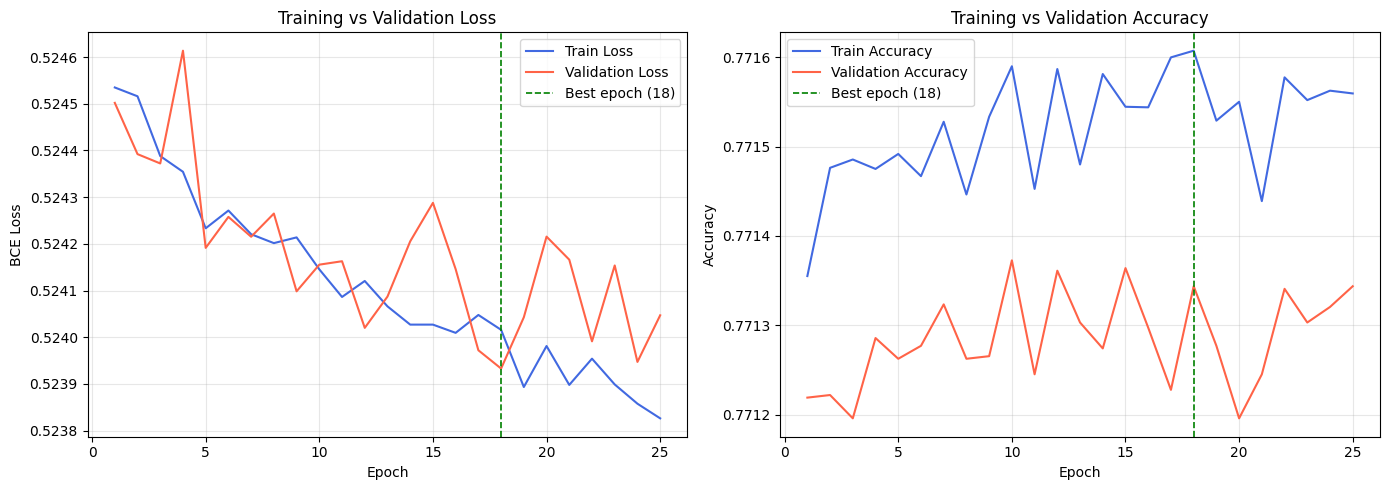

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(train_losses) + 1)

# Loss curves
ax1.plot(epochs_ran, train_losses, label='Train Loss',      color='royalblue')
ax1.plot(epochs_ran, val_losses,   label='Validation Loss', color='tomato')
ax1.axvline(best_epoch, color='green', linestyle='--', linewidth=1.2, label=f'Best epoch ({best_epoch})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(epochs_ran, train_accs, label='Train Accuracy',      color='royalblue')
ax2.plot(epochs_ran, val_accs,   label='Validation Accuracy', color='tomato')
ax2.axvline(best_epoch, color='green', linestyle='--', linewidth=1.2, label=f'Best epoch ({best_epoch})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Evaluate neural network on validation set for comparison
_, nn_val_acc, nn_val_probs, nn_val_labels = evaluate_epoch(model, val_loader, criterion, device)
nn_val_metrics = classification_metrics(nn_val_labels, nn_val_probs)

print('Neural Network (Validation Set):')
for key, value in nn_val_metrics.items():
    print(f'\t{key}: {value:.4f}')

Neural Network (Validation Set):
	Accuracy: 0.7713
	Precision: 0.7690
	Recall: 0.9990
	F1: 0.8690
	AUC-ROC: 0.6188


The neural network model has slighlty high accuracy, recall and f1 values compared to the logistic regression and random forest classifier models. The AUC-ROC score was slightly higher when compared to the random forest classifer but had a much more significant increase when compared to the logistic regression model. Regarding precision, the neural network model has the same precision value as the logistic regression model but is slightly less precise han the random forest classifier model.

#Part 3: Model Evaluation & Interpretation

##Comprehensive Evaluation

In [ ]:
#Evaluate all trained models on the held-out test set

#Regression models
#Linear Regression
ln_reg_pred_test = ln_reg.predict(X_test_scaled)
ln_reg_test_metrics = regression_metrics(y_reg_test, ln_reg_pred_test)

#Random Forest Regressor
rf_reg_pred_test = rf_reg.predict(X_test_scaled)
rf_reg_test_metrics = regression_metrics(y_reg_test, rf_reg_pred_test)

#Tuned Random Forest
rf_reg_tuned_pred_test = rf_reg_tuned.predict(X_test_scaled)
rf_reg_tuned_test_metrics = regression_metrics(y_reg_test, rf_reg_tuned_pred_test)

#Classifier models
#Logistic Regression
lr_class_prob_test  = lr_class.predict_proba(X_test_scaled)[:, 1]
lr_class_test_metrics  = classification_metrics(y_class_test, lr_class_prob_test)

#Random Forest Classifier
rf_class_prob_test  = rf_class.predict_proba(X_test_scaled)[:, 1]
rf_class_test_metrics  = classification_metrics(y_class_test, rf_class_prob_test)

#Neural Network
_, nn_test_acc, nn_test_probs, nn_test_labels = evaluate_epoch(model, test_loader, criterion, device)
nn_test_metrics = classification_metrics(nn_test_labels, nn_test_probs)

In [ ]:
import pandas as pd

#Summary Table
results = pd.DataFrame([
    #Regression models
    ["Linear Regression",
     ln_reg_test_metrics["MAE"], ln_reg_test_metrics["RMSE"], ln_reg_test_metrics["R2"],
     None, None, None, None, None],

    ["Baseline Random Forest",
     rf_reg_test_metrics["MAE"], rf_reg_test_metrics["RMSE"], rf_reg_test_metrics["R2"],
     None, None, None, None, None],

    ["Tuned Random Forest",
     rf_reg_tuned_test_metrics["MAE"], rf_reg_tuned_test_metrics["RMSE"], rf_reg_tuned_test_metrics["R2"],
     None, None, None, None, None],

    #Classification models
    ["Logistic Regression",
     None, None, None,
     lr_class_test_metrics["Accuracy"], lr_class_test_metrics["Precision"],
     lr_class_test_metrics["Recall"], lr_class_test_metrics["F1"], lr_class_test_metrics["AUC-ROC"]],

    ["Random Forest (Classifier)",
     None, None, None,
     rf_class_test_metrics["Accuracy"], rf_class_test_metrics["Precision"],
     rf_class_test_metrics["Recall"], rf_class_test_metrics["F1"], rf_class_test_metrics["AUC-ROC"]],

    ["Neural Network",
     None, None, None,
     nn_test_metrics["Accuracy"], nn_test_metrics["Precision"],
     nn_test_metrics["Recall"], nn_test_metrics["F1"], nn_test_metrics["AUC-ROC"]],
],
columns=[
    "Model",
    "MAE", "RMSE", "R2",
    "Accuracy", "Precision", "Recall", "F1", "AUC-ROC"
])

print("TEST SET RESULTS")
print(results.round(4))

TEST SET RESULTS
                        Model     MAE    RMSE      R2  Accuracy  Precision  \
0           Linear Regression  1.2132  2.2984  0.6386       NaN        NaN   
1      Baseline Random Forest  1.1979  2.3379  0.6261       NaN        NaN   
2         Tuned Random Forest  1.1917  2.2839  0.6432       NaN        NaN   
3         Logistic Regression     NaN     NaN     NaN    0.7711     0.7691   
4  Random Forest (Classifier)     NaN     NaN     NaN    0.7709     0.7691   
5              Neural Network     NaN     NaN     NaN    0.7713     0.7690   

   Recall      F1  AUC-ROC  
0     NaN     NaN      NaN  
1     NaN     NaN      NaN  
2     NaN     NaN      NaN  
3  0.9982  0.8688   0.6091  
4  0.9979  0.8687   0.6156  
5  0.9989  0.8690   0.6189  


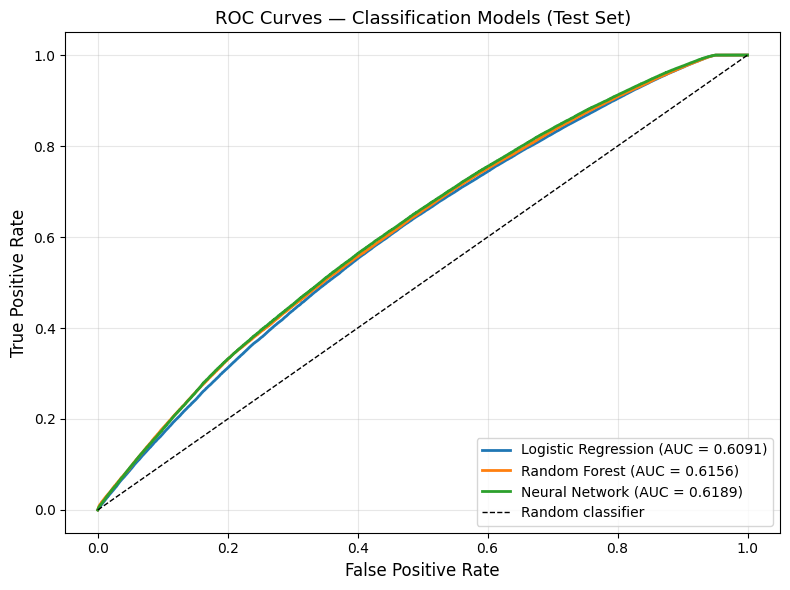

In [ ]:
#ROC curves for classification models
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

for name, y_prob in [
    ('Logistic Regression', lr_class_prob_test),
    ('Random Forest', rf_class_prob_test),
    ('Neural Network', nn_test_probs),
]:
    fpr, tpr, _ = roc_curve(y_class_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Classification Models (Test Set)', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Best classifier: Neural Network


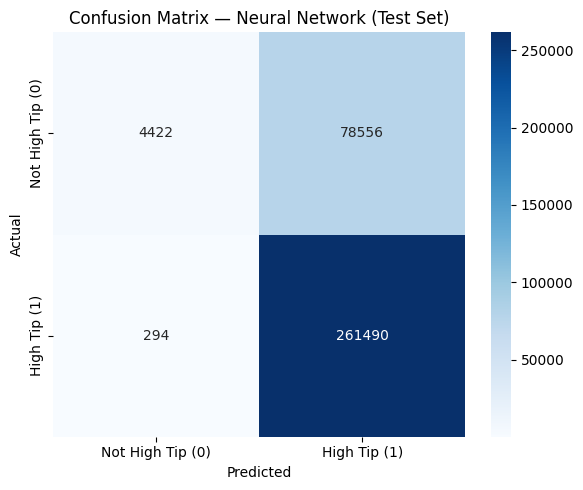

In [ ]:
#Confusion matrix for best classification model
import seaborn as sns
from sklearn.metrics import confusion_matrix

#Determine best classifier
class_results = {
    'Logistic Regression': (lr_class_prob_test, lr_class_test_metrics['AUC-ROC']),
    'Random Forest': (rf_class_prob_test,  rf_class_test_metrics['AUC-ROC']),
    'Neural Network': (nn_test_probs,        nn_test_metrics['AUC-ROC']),
}
best_clf_name = max(class_results, key=lambda k: class_results[k][1])
best_clf_probs = class_results[best_clf_name][0]
best_clf_preds = (best_clf_probs >= 0.5).astype(int)

print(f'Best classifier: {best_clf_name}')
cm = confusion_matrix(y_class_test, best_clf_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High Tip (0)', 'High Tip (1)'],
            yticklabels=['Not High Tip (0)', 'High Tip (1)'],
            ax=ax)
ax.set_title(f'Confusion Matrix — {best_clf_name} (Test Set)', fontsize=12)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1653/1617202546.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('pred_vs_actual.png', dpi=150, bbox_inches='tight')


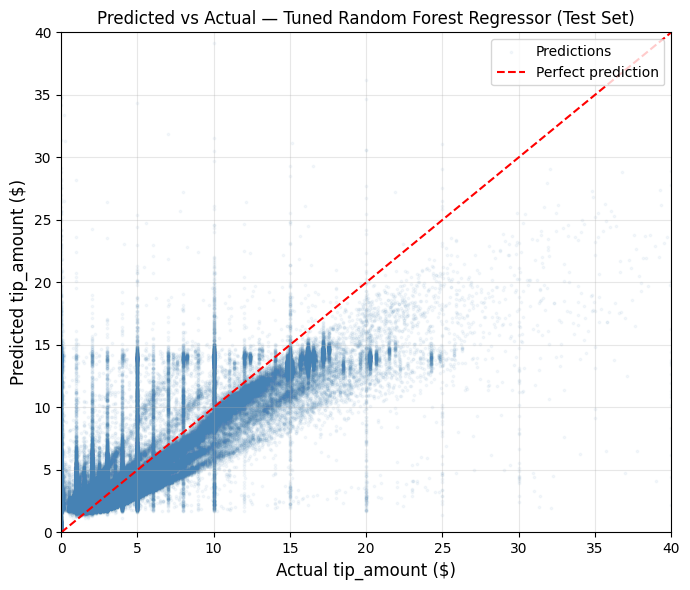

In [ ]:
#Scatter plot of predicted vs actual tip amounts for thebest model
#Tuned random forest regressor is best
best_reg_preds = rf_reg_tuned_pred_test  # tuned RF is best

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_reg_test, best_reg_preds, alpha=0.05, s=3, color='steelblue', label='Predictions')
lims = [max(y_reg_test.min(), best_reg_preds.min()),
        min(y_reg_test.max(), best_reg_preds.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual tip_amount ($)', fontsize=12)
ax.set_ylabel('Predicted tip_amount ($)', fontsize=12)
ax.set_title('Predicted vs Actual — Tuned Random Forest Regressor (Test Set)', fontsize=12)
ax.set_xlim([0, 40])
ax.set_ylim([0, 40])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

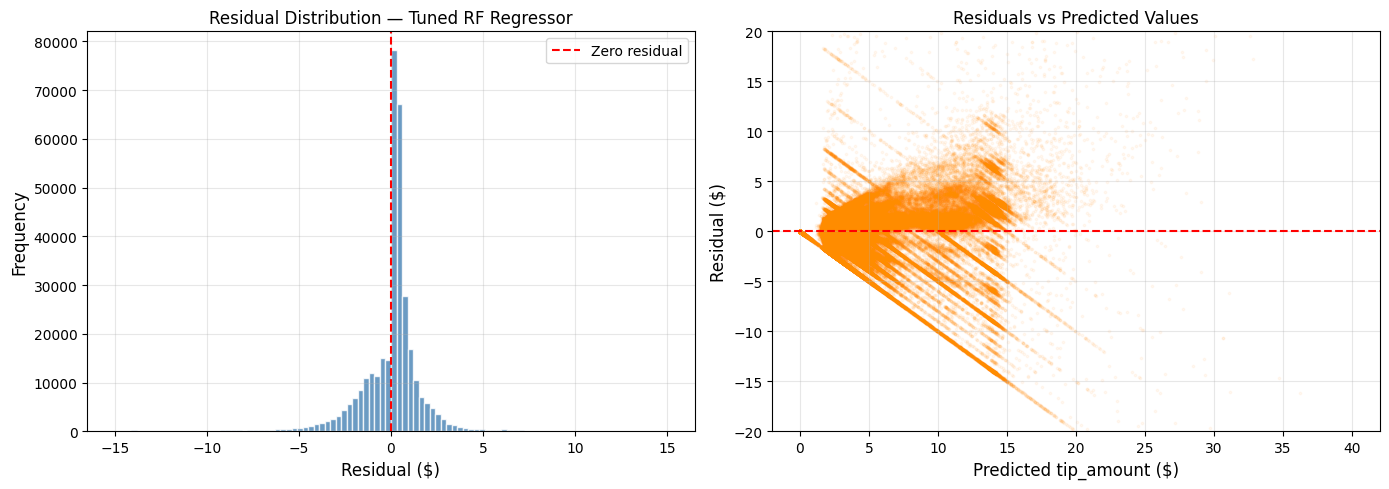

Residual statistics:
	Mean:	0.0027
	Std:	2.2839
 	Median:	0.2552


In [ ]:
#Residual analysis for the best regression model
residuals = y_reg_test - best_reg_preds

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Residual distribution
ax1.hist(residuals, bins=100, color='steelblue', edgecolor='white', alpha=0.8, range=(-15, 15))
ax1.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero residual')
ax1.set_xlabel('Residual ($)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Residual Distribution — Tuned RF Regressor', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

#Residuals vs predicted values
ax2.scatter(best_reg_preds, residuals, alpha=0.05, s=3, color='darkorange')
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Predicted tip_amount ($)', fontsize=12)
ax2.set_ylabel('Residual ($)', fontsize=12)
ax2.set_title('Residuals vs Predicted Values', fontsize=12)
ax2.set_ylim([-20, 20])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Residual statistics:')
print(f'\tMean:\t{residuals.mean():.4f}')
print(f'\tStd:\t{residuals.std():.4f}')
print(f' \tMedian:\t{np.median(residuals):.4f}')

#Feature Importance

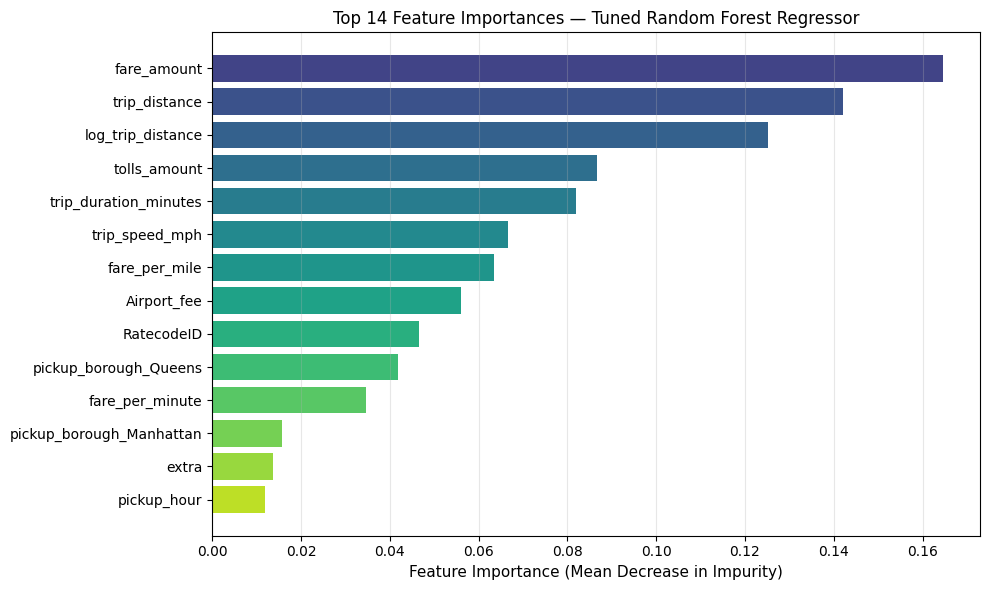

Rank   Feature                               Importance
-------------------------------------------------------
1      fare_amount                               0.1647
2      trip_distance                             0.1421
3      log_trip_distance                         0.1251
4      tolls_amount                              0.0867
5      trip_duration_minutes                     0.0819
6      trip_speed_mph                            0.0665
7      fare_per_mile                             0.0634
8      Airport_fee                               0.0560
9      RatecodeID                                0.0465
10     pickup_borough_Queens                     0.0419
11     fare_per_minute                           0.0345
12     pickup_borough_Manhattan                  0.0156
13     extra                                     0.0136
14     pickup_hour                               0.0118


In [ ]:
#Random forest feature importances
importances = rf_reg_tuned.feature_importances_
indices     = np.argsort(importances)[::-1]

cumulative = np.cumsum(importances[indices])
top_n = np.searchsorted(cumulative, 0.95) + 1
top_idx   = indices[:top_n]
top_names = [feature_columns[i] for i in top_idx]
top_imps  = importances[top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, top_n))
bars = ax.barh(range(top_n), top_imps[::-1], color=colors[::-1])
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_names[::-1], fontsize=10)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title(f'Top {top_n} Feature Importances — Tuned Random Forest Regressor', fontsize=12)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{"Rank":<6} {"Feature":<35} {"Importance":>12}')
print('-' * 55)
for rank, (i, imp) in enumerate(zip(top_idx, top_imps), 1):
    print(f'{rank:<6} {feature_columns[i]:<35} {imp:>12.4f}')

In [ ]:
#Extract and interpret coefficients from Linear and Logistic Regression
lr_coefficients = pd.DataFrame({
    'Feature': feature_columns,
    'Linear Regression Coefficient': ln_reg.coef_,
    'Logistic Regression Coefficient': lr_class.coef_[0]
}).sort_values('Linear Regression Coefficient', ascending=False)

print(lr_coefficients.to_string(index=False))

                      Feature  Linear Regression Coefficient  Logistic Regression Coefficient
                  fare_amount                       2.287043                        -0.220741
            log_trip_distance                       0.502868                        -0.410834
                 tolls_amount                       0.423782                         0.098610
         congestion_surcharge                       0.207144                         0.097076
       dropoff_borough_Queens                       0.192716                         0.111433
     dropoff_borough_Brooklyn                       0.168352                         0.125742
                        extra                       0.157259                         0.050463
                  Airport_fee                       0.153891                         0.034619
    dropoff_borough_Manhattan                       0.144505                         0.096658
        pickup_borough_Queens                       0.090701

##Written Analysis

###Which model performed best for each task and why you think this is the case?
**Regression (predict tip_amount):** The tuned random forest regressor performed the best out of all the regression models by all metrics (MAE, RMSE and R²).

**Classification (predict high_tip or not):** All three models performed similarly with the neural network model having a slight edge over the other two (except regarding precision). However, both the neural network model and ranom forest classifier had notable improvements in AUC-ROC scores compared to logistic regression model which may point to their greater capabilities of capturing non-linear interactions between features.

###What features are most predictive of tip amount and whether this aligns with your intuition
fare_amount and trip_distance were most predictive of tip_amount. This aligns with my intuition that amount being tipped is proportional to the fare being paid, as well as, the fare being based on the distance of the trip

###Limitations of your models
1. The model only accounts for tips made for credit card payments as tip_amount is only reliably recorded for credit card payments. People paying with cash may generally tip differently.
2. The dataset only covers one month (January 2024). Tipping behaviour might differ substantially depending on the time of the year and in response to current, external events.


###Potential improvements
1. Use SHAP values to explain individual predictions, making the model/s more easily interpretable
2. Processing a larger dataset that covers a greater period of time and payment types.

###Brief discussion comparing the neural network approach to the traditional ML models for this particular problem
This particular problem handles tabular data with engineered features which traditional tree based-methods generally perform better at. In this case, even though the neural network model performed slighly better in most metrics than the random forest classifier model, the difference was minimal and it was also slightly less precise.
Generally, neural networks perform better with non-tabular data that contains a temporal, spatial or sequential structure, with much larger datasets than the one this problem analyses and when layers can embed high-cardinality categories more efficiently than one-hot encoding.
The opposite is true for a more traditional ML model so a neural network model is likely not the right choice for this particular problem

#AI Disclosure
Chatgpt was used for error troubleshooting. Claude was used to give me a starting point for areas where I wasn't sure how to tackle, as well as, for enhancing certain aspects like chart appearances.

###